# 03 — Customer value & purchase behavior
### Olist Brazilian E-Commerce · `retail-platform-analytics`

The obvious next step after the EDA was a **customer segmentation** — the classic *RFM* model
(**R**ecency, **F**requency, **M**onetary). But on Olist all three RFM axes fall short:
- **Frequency ≈ 1** — ~97% of customers order only once, so it can't tell anyone apart.
- **Monetary is circular** — a customer's spend *is* their revenue, so grouping by it and concluding
  "big spenders drive revenue" is a tautology, not an insight.
- **Recency** only records *when a customer ordered within our window*, not a behavioural or loyalty
  pattern (and, as we'll see, it can't even distinguish new from returning customers).

So instead of forcing RFM, this notebook asks two better questions: **what actually makes a customer
valuable** (answer: the *price-point* of what they buy), and **why don't customers come back** (answer:
a mix of a short data window and Olist behaving like a one-off marketplace). §1 confirms the RFM
collapse with data; the rest builds the alternative.

## Data caveats & conventions

- **Grain:** one row per customer, from `fct_order_items` joined to `fct_orders`, aggregated to the
  person-level `customer_id` (resolved to `customer_unique_id` in dbt — see `01`).
- **Ticket** = a customer's average item price; **value** = their total item revenue.
- **⚠️ Windowed data (matters for the repeat analysis):** orders span **Sep 2016 – Oct 2018 (~2.1
  years)**. We see only orders *inside* this window, which creates two blind spots used explicitly in
  §5: a first order *in the window* may not be a customer's true first order (**left-censoring**), and
  customers acquired late had little time to repurchase (**right-censoring**).
- **⚠️ No product-cost data**, so "value" is revenue, not margin (margin is proxied by freight in `04`).

## Setup

In [1]:
import sys
sys.path.insert(0, ".")
import db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    df = db.query(sql)
    df.columns = df.columns.str.lower()
    return df

# One customer-level pull reused throughout: orders, items, spend, and average ticket per customer.
cust = q('''
    select o.customer_id,
           count(distinct oi.order_id) as n_orders,   -- frequency
           count(*)                    as n_items,     -- basket size (total items bought)
           sum(oi.total_item_value)    as total_value, -- the customer's revenue
           avg(oi.price)               as avg_ticket   -- typical price point they buy at
    from dev_marts.fct_order_items oi
    join dev_marts.fct_orders o on oi.order_id = o.order_id
    group by 1
''')
for c in ["n_orders", "n_items", "total_value", "avg_ticket"]:
    cust[c] = pd.to_numeric(cust[c], errors="coerce")
print(f"{len(cust):,} customers")

95,420 customers


## 1. Confirming the RFM collapse

The intro claims Frequency and basket size are both flat. Here's the proof. (Note **basket size** —
items per order — is *not* an RFM axis; it's the obvious fallback, and it's just as flat.)

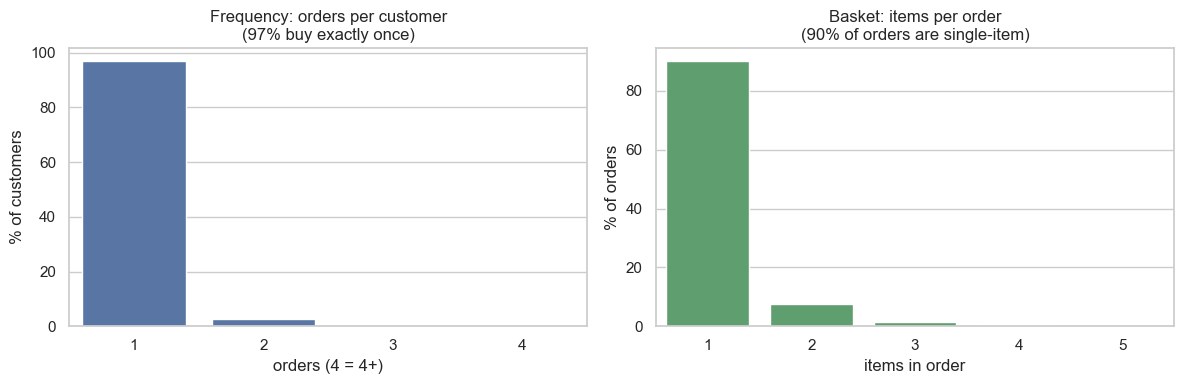

Frequency: 96.9% order once | Basket: 90.1% of orders are single-item


In [2]:
# Frequency (orders per customer) and basket size (items per order) — do they vary?
freq_one = 100 * (cust["n_orders"] == 1).mean()
basket = q('''
    select n_items, count(*) as orders
    from (select order_id, count(*) as n_items from dev_marts.fct_order_items group by 1)
    group by 1 order by 1
''')
basket["pct"] = 100 * basket["orders"] / basket["orders"].sum()
basket_one = basket.loc[basket["n_items"] == 1, "pct"].iloc[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
oc = cust["n_orders"].clip(upper=4).value_counts(normalize=True).sort_index() * 100  # Frequency axis
sns.barplot(x=oc.index, y=oc.values, ax=ax1, color="#4C72B0")
ax1.set_title(f"Frequency: orders per customer\n({freq_one:.0f}% buy exactly once)")
ax1.set_xlabel("orders (4 = 4+)"); ax1.set_ylabel("% of customers")
sns.barplot(data=basket[basket["n_items"] <= 5], x="n_items", y="pct", ax=ax2, color="#55A868")  # basket size
ax2.set_title(f"Basket: items per order\n({basket_one:.0f}% of orders are single-item)")
ax2.set_xlabel("items in order"); ax2.set_ylabel("% of orders")
plt.tight_layout(); plt.show()
print(f"Frequency: {freq_one:.1f}% order once | Basket: {basket_one:.1f}% of orders are single-item")

**Confirmed.** Frequency ≈ 1 and basket ≈ 1 — neither varies enough to segment on, and Monetary is
circular. RFM has no traction here, so we pivot to decomposing *what makes a customer valuable*.

## 2. What drives customer value — ticket, not quantity

A customer's value ≈ **number of items × average item price**. Correlate value with each to see which
does the work.

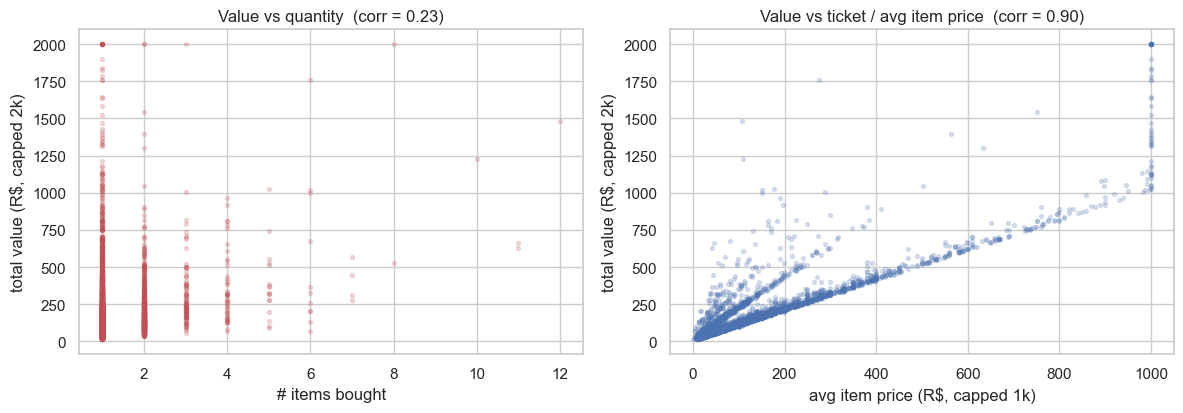

corr(value, #items) = 0.23   vs   corr(value, ticket) = 0.90


In [3]:
corr_qty = cust["total_value"].corr(cust["n_items"])
corr_ticket = cust["total_value"].corr(cust["avg_ticket"])

s = cust.sample(min(6000, len(cust)), random_state=1)  # sample for readable scatters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.scatter(s["n_items"], s["total_value"].clip(upper=2000), s=8, alpha=0.2, color="#C44E52")
ax1.set_title(f"Value vs quantity  (corr = {corr_qty:.2f})")
ax1.set_xlabel("# items bought"); ax1.set_ylabel("total value (R$, capped 2k)")
ax2.scatter(s["avg_ticket"].clip(upper=1000), s["total_value"].clip(upper=2000), s=8, alpha=0.2, color="#4C72B0")
ax2.set_title(f"Value vs ticket / avg item price  (corr = {corr_ticket:.2f})")
ax2.set_xlabel("avg item price (R$, capped 1k)"); ax2.set_ylabel("total value (R$, capped 2k)")
plt.tight_layout(); plt.show()
print(f"corr(value, #items) = {corr_qty:.2f}   vs   corr(value, ticket) = {corr_ticket:.2f}")

**Value is a ticket story, not a quantity story.** Value tracks average item price at **≈0.90** but
item count at only **≈0.23**. Valuable customers buy *pricier things*, not *more things* — so the useful
question is *what price-point (and product) they buy at*.

## 3. Grouping by price — is there a *natural* cut?

Before drawing tier boundaries, check whether the data has natural price clusters or is a smooth
continuum. We run a simple 1-D k-means over customer ticket (on a log scale) and look at how much ticket
variance each additional cluster explains — a sharp "elbow" would signal natural groups.

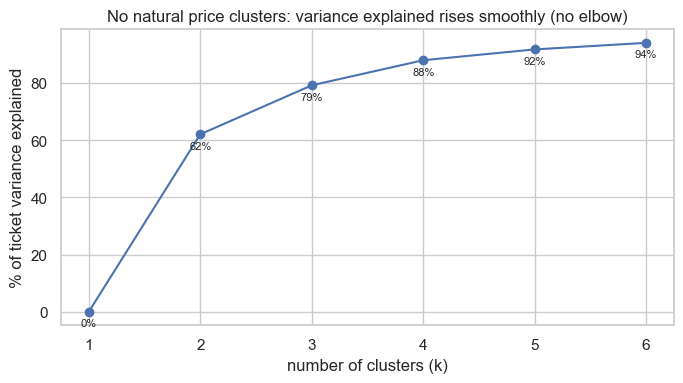

In [4]:
# Minimal 1-D k-means (Lloyd's) to test for natural clusters in log-ticket.
x = np.log10(cust["avg_ticket"].clip(lower=1).values)
def kmeans_1d(x, k, iters=50):
    c = np.quantile(x, np.linspace(0.1, 0.9, k))          # spread initial centroids
    for _ in range(iters):
        lab = np.abs(x[:, None] - c[None, :]).argmin(1)
        nc = np.array([x[lab == j].mean() if (lab == j).any() else c[j] for j in range(k)])
        if np.allclose(nc, c): break
        c = nc
    return ((x - c[lab]) ** 2).sum()                       # within-cluster variance (inertia)

total_var = ((x - x.mean()) ** 2).sum()
ks = range(1, 7)
var_explained = [100 * (1 - (kmeans_1d(x, k) if k > 1 else total_var) / total_var) for k in ks]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), var_explained, marker="o", color="#4C72B0")
ax.set_title("No natural price clusters: variance explained rises smoothly (no elbow)")
ax.set_xlabel("number of clusters (k)"); ax.set_ylabel("% of ticket variance explained")
for k, v in zip(ks, var_explained):
    ax.text(k, v - 5, f"{v:.0f}%", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

**No natural clusters.** The curve climbs smoothly (k=2→62%, 3→79%, 4→88%, 5→92%) with **no
elbow** — price is a continuous, right-skewed distribution, not distinct clumps. So any tiering is a
transparent *modeling choice*, not a discovered structure. We use **quintiles** (five equal-sized
groups) — objective and easy to read.

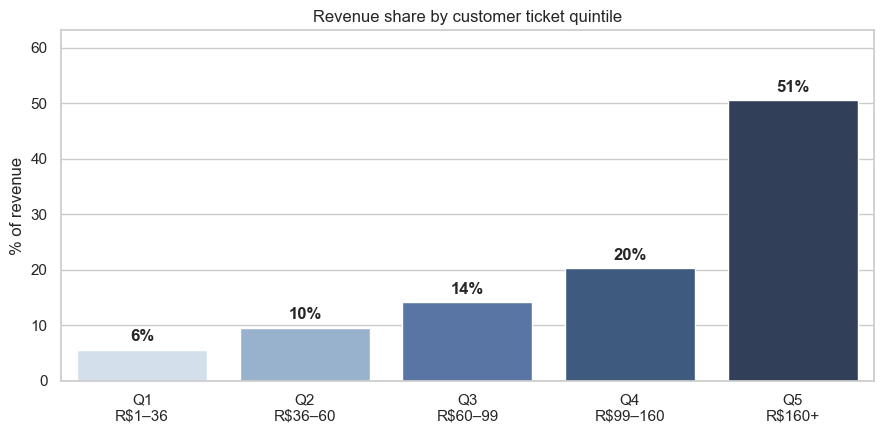

,quintile,lo,hi,customers,avg_items,rev_share
0,Q1,0.80,35.90,19084,1.20,5.60
1,Q2,35.90,59.90,19084,1.20,9.50
2,Q3,59.90,99.50,19084,1.20,14.10
3,Q4,99.50,159.80,19084,1.10,20.30
4,Q5,159.80,"6,735.00",19084,1.10,50.50


In [5]:
# Quintiles by ticket (rank first so the five groups are exactly equal despite ties).
cust["quintile"] = pd.qcut(cust["avg_ticket"].rank(method="first"), 5,
                           labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
qt = cust.groupby("quintile", observed=True).agg(
    lo=("avg_ticket", "min"), hi=("avg_ticket", "max"),
    customers=("customer_id", "size"), avg_items=("n_items", "mean"),
    revenue=("total_value", "sum")).reset_index()
qt["rev_share"] = 100 * qt["revenue"] / qt["revenue"].sum()
# x labels carry the price range so it lives OUTSIDE the plotting area (keeps bars uncluttered).
qt["label"] = [f"{r.quintile}\nR${r.lo:,.0f}–{r.hi:,.0f}" if r.quintile != "Q5"
               else f"{r.quintile}\nR${r.lo:,.0f}+" for r in qt.itertuples()]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=qt, x="label", y="rev_share", ax=ax, hue="label",
            palette=["#cfe0f0", "#8FB0D6", "#4C72B0", "#345888", "#2A3F5F"], legend=False, dodge=False)
ax.set_ylim(0, qt["rev_share"].max() * 1.25)              # headroom so labels aren't clipped
ax.set_title("Revenue share by customer ticket quintile"); ax.set_xlabel(""); ax.set_ylabel("% of revenue")
for i, r in qt.iterrows():
    ax.text(i, r["rev_share"] + 1.5, f"{r['rev_share']:.0f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
qt[["quintile", "lo", "hi", "customers", "avg_items", "rev_share"]].round(1)

**Value is extremely top-concentrated.** Revenue share climbs 6% → 10% → 14% → 20% → **50%** across
quintiles: the **top 20% of customers (avg ticket > ~R$160) drive half of all revenue** — at the same
~1.1 basket size as everyone else. And even this top quintile hides a long tail: the ~3% of customers
above R$500 alone account for ~20% of revenue. **⚠️ But a quintile is a *price* band, not a product
type** — R$160+ lumps a R$300 watch with R$300 of cosmetics and R$3k of furniture. The next section
looks at what's actually inside.

## 4. What each price group buys

Price bands mix products, so look at the *categories* inside the bottom vs top quintile.

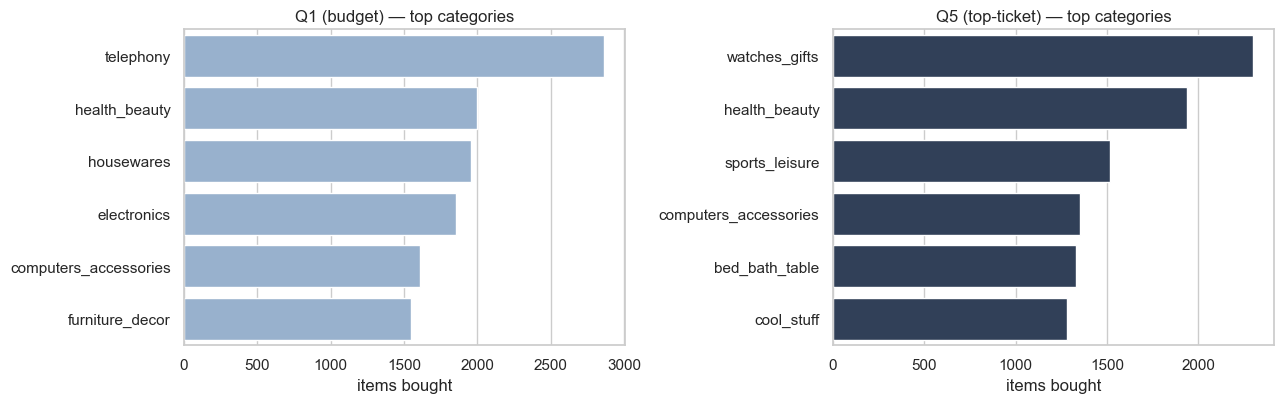

In [6]:
# Item categories tagged with each customer's ticket quintile.
items = q('''
    select o.customer_id, oi.category_name
    from dev_marts.fct_order_items oi
    join dev_marts.fct_orders o on oi.order_id = o.order_id
    where oi.category_name is not null
''').merge(cust[["customer_id", "quintile"]], on="customer_id")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, qn, color in [(axes[0], "Q1", "#8FB0D6"), (axes[1], "Q5", "#2A3F5F")]:
    top = items[items["quintile"] == qn]["category_name"].value_counts().head(6)
    sns.barplot(x=top.values, y=top.index, ax=ax, color=color)
    ax.set_title(f"{qn} ({'budget' if qn=='Q1' else 'top-ticket'}) — top categories")
    ax.set_xlabel("items bought"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Budget vs top-ticket buy different things** — Q1 clusters in cheap phone/home goods
(`telephony`, `housewares`, `bed_bath_table`), Q5 in `watches_gifts`, `computers_accessories`, and
premium `health_beauty`. But note Q5's mix itself spans a durable watch, a computer, and a consumable
cosmetic — **price groups customers, product category tells you *what kind* of customer**. The two
together (high ticket + which category) are what's actually actionable, tying back to `04`'s margin
view (watches & health-beauty are the margin-safe drivers).

## 5. Why don't customers come back?

Only ~3% of customers ever order twice. It's tempting to conclude "no loyalty" — but as an analyst that
deserves scrutiny, because our 2-year window and Olist's catalog both bias this downward. Let's separate
the explanations rather than assert one.

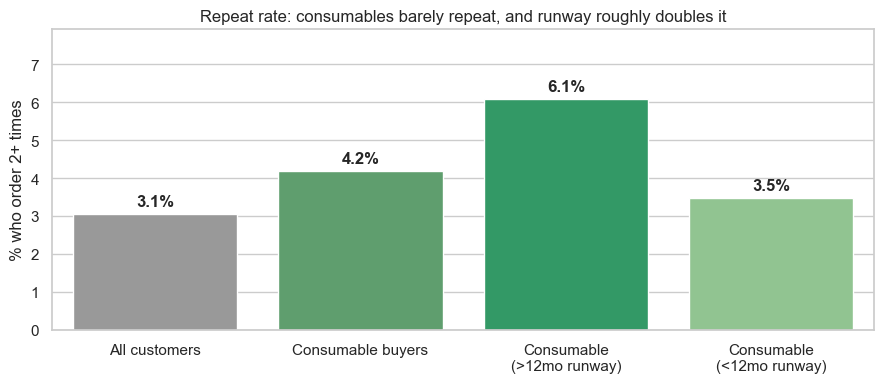

In [7]:
CONS = "('health_beauty','perfumery','food','drinks','food_drink','diapers_and_hygiene','pet_shop','flowers')"

overall_repeat = 100 * (cust["n_orders"] >= 2).mean()
cons_repeat = q(f'''
    with cons as (select distinct o.customer_id
                  from dev_marts.fct_order_items oi join dev_marts.fct_orders o on oi.order_id=o.order_id
                  where oi.category_name in {CONS}),
         oc as (select customer_id, count(distinct order_id) n from dev_marts.fct_orders group by 1)
    select 100.0*avg(iff(oc.n>=2,1,0)) p from cons join oc using(customer_id)
''').iloc[0, 0]
# Split consumable buyers by how much runway they had to repurchase before the window closed.
runway = q(f'''
    with cons as (select o.customer_id, min(o.purchased_at) fo
                  from dev_marts.fct_order_items oi join dev_marts.fct_orders o on oi.order_id=o.order_id
                  where oi.category_name in {CONS} group by 1),
         oc as (select customer_id, count(distinct order_id) n from dev_marts.fct_orders group by 1)
    select case when cons.fo < dateadd('month',-12,(select max(purchased_at) from dev_marts.fct_orders))
                then 'early (>12mo runway)' else 'late (<12mo runway)' end cohort,
           100.0*avg(iff(oc.n>=2,1,0)) repeat_pct
    from cons join oc using(customer_id) group by 1 order by 1
''')

bars = pd.DataFrame({
    "group": ["All customers", "Consumable buyers", "Consumable\n(>12mo runway)", "Consumable\n(<12mo runway)"],
    "repeat_pct": [overall_repeat, cons_repeat,
                   runway.loc[runway.cohort.str.startswith("early"), "repeat_pct"].iloc[0],
                   runway.loc[runway.cohort.str.startswith("late"), "repeat_pct"].iloc[0]]})
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=bars, x="group", y="repeat_pct", ax=ax, hue="group",
            palette=["#999", "#55A868", "#2A6", "#8c8"], legend=False, dodge=False)
ax.set_ylim(0, bars["repeat_pct"].max() * 1.3)
ax.set_title("Repeat rate: consumables barely repeat, and runway roughly doubles it")
ax.set_xlabel(""); ax.set_ylabel("% who order 2+ times")
for i, r in bars.iterrows():
    ax.text(i, r["repeat_pct"] + 0.2, f"{r['repeat_pct']:.1f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Four explanations, and the data lets us weigh them:**

1. **Left-censoring — we can't identify *new* customers.** The data starts Sep 2016; a "first order in
   the window" may be a returning customer whose earlier orders we simply don't see. So the whole
   "one-and-done" read is measured *within* the window, not over customers' lifetimes.
2. **Right-censoring — short runway.** Customers acquired late in the window had little time to
   repurchase. Evidence: consumable buyers with **>12 months of runway repeat at ~6.1%** vs **~3.5%**
   for late arrivals — runway roughly **doubles** observed repeat. So the ~2-year window genuinely
   suppresses repeat.
3. **Long repurchase cycles (durables).** The catalog is dominated by durables (furniture, electronics,
   watches) that repurchase over *years* — a horizon a 2-year window can't see. *But* note the few
   repeaters we do see return in a **median of ~28 days**, so long cycles don't explain the repeaters,
   only the (invisible) potential ones.
4. **One-off / discretionary channel.** Even with 12+ months of runway, **~94% of consumable buyers
   never return**, and consumables were on the platform the whole time (not a recent addition). That
   points to Olist being used for discretionary/one-off purchases, with routine replenishment happening
   elsewhere (supermarkets, pharmacies).

**Honest synthesis:** low observed repeat is *both* a data-window artifact **and** genuine one-off
behaviour — and we can't fully separate them here. A live/incremental pipeline (removing the censoring)
is what would settle it.

## 6. Findings & recommendations

### What we found
1. **RFM doesn't apply** — Frequency ≈1, basket ≈1, Monetary circular. We pivoted to price-point.
2. **Value is driven by ticket, not quantity** (corr ≈0.90 vs ≈0.23), and it is **extremely
   top-concentrated**: the top ticket quintile (>~R$160) is ~50% of revenue; the top ~3% (>R$500) ≈20%.
3. **Price groups ≠ product types** — the useful signal is high ticket *combined with* category
   (watches, computers, premium health & beauty).
4. **Low repeat is multi-causal** — part data-window censoring (runway doubles observed repeat), part
   Olist behaving as a one-off channel (even long-runway consumable buyers rarely return).

### Recommendations (if live)
- **Grow value via acquisition & merchandising** — attract customers into high-ticket, margin-safe
  categories (watches, health & beauty, computers) and raise the entry price-point (upsell at checkout).
- **Test frequency-building carefully.** Cross-selling frequently-repurchased low-ticket consumables to
  big-ticket buyers is a plausible lever *if margins allow* — but the data suggests Olist isn't currently
  a replenishment channel, so treat it as a **hypothesis to A/B test**, not a sure thing.
- **Don't declare "no loyalty" on this data.** The window can't observe durable repurchase cycles or
  pre-window history — measure retention properly on a live pipeline before concluding.

### Backlog
The missing dimension is genuine **cohort retention over time**, which this static ~2-year snapshot
(with left/right censoring) cannot support — the top item for a future live/incremental pipeline.